In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import pickle
import deepRD.tools.trajectoryTools as trajectoryTools
import csv
import math
from deepRD.noiseSampler import noiseSampler
from torchvision.transforms import ToTensor
from torch import nn
from torch.utils.data import DataLoader
from sklearn.neighbors import KernelDensity
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from scipy.stats import gaussian_kde, wasserstein_distance_nd

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [8]:
# System type: 'bistable', 'dimer'
systemType = 'bistable'

# Conditioning variables: piri, piririm, pipimri, etc. - for dimer, piridqi

# datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim for benchmark
# for dimer, alternating between particle 1 and particle 2.

#for generated trajs, 
# datapoint = [time (1), qi (3), vi (3), ri(3)] - 10 dim

# Datasets directory
localDirectoryBase = "/group/ag_cmb/scratch/maojrs/stochasticClosure/" + systemType + "/boxsize5/"

# loading multiple simulation folders for comparisons, and corresponding labels

datasetFolders = ["benchmarkReducedGen_pipimririm/", "benchmarkReducedGen_piririm/", "benchmarkReducedGen_piririmrimm/"]
datasetLabels = ["pipimririm", "piririm", "piririmrimm"]
nModels = len(datasetFolders)

nTrajs = 100 # no. of trajectories to load per data folder

nTimestepsBench = 10000 # length of benchmark trajectory
nTimesteps = 200000 # length of coarse-grained trajectory
datapointDim = 10 # dimensionality of datapoints.
numFilesBench = 2500
numFiles = 100 # total no. of files in data folder

# Initialising tensor to store trajectories
dataset = torch.empty((nModels, nTrajs, nTimesteps, datapointDim))
    
# Loading reduced models data

truncate = False # if True, will select random fragment of trajectory

for i, datasetFolder in enumerate(datasetFolders):
    
    filePath = localDirectoryBase + datasetFolder + "simMoriZwanzigReduced_"    
    
    fileIDS = np.sort(np.random.choice(numFiles, nTrajs, replace=False))
    if i==1:
        print(fileIDS)
    
    for j, fnum in enumerate(fileIDS):
        try:
            ds = torch.Tensor(trajectoryTools.loadTrajectory(filePath, fnum))
        except FileNotFoundError:
            print(f'File {fnum} not available')
            continue
            
        dataset[i, j] = ds

#dataset_norm = (dataset[0] - mean_d)/std_d
dataset.shape # nModels, nTrajs, nTimesteps, datapointDims

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]


torch.Size([3, 100, 200000, 10])

In [9]:
# Loading Benchmark data

benchDataset = torch.empty((nTrajs, nTimestepsBench, datapointDim))

fileIDS = np.sort(np.random.choice(numFilesBench, nTrajs, replace=False))

benchFileDirectory = localDirectoryBase + "benchmark/simMoriZwanzig_"

for j, fnum in enumerate(fileIDS):
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(benchFileDirectory, fnum))
    except FileNotFoundError:
        print(f'File {fnum} not available')
        continue

    # cutting out meaningless variable
    if ds.shape[1]==11:
        ds = torch.cat((ds[:, :7], ds[:, -3:]), dim=1)
    
    benchDataset[j] = ds
    
benchDataset.shape

torch.Size([100, 10000, 10])

In [10]:
b_timesteps = benchDataset[:, :, 0]
b_qT = benchDataset[:, :, 1:4]
b_rAuxT = benchDataset[:, :, -3:]
b_rNxtT = torch.roll(b_rAuxT, -1, 1)
b_vT = benchDataset[:, :, 4:7]

timesteps = dataset[:, :, :, 0]
qT = dataset[:, :, :, 1:4]
rAuxT = dataset[:, :, :, -3:]
rNxtT = torch.roll(rAuxT, -1, 2)
vT = dataset[:, :, :, 4:7]

b_timesteps.shape, b_qT.shape, b_rAuxT.shape, b_rNxtT.shape, b_vT.shape, timesteps.shape, qT.shape, rAuxT.shape, rNxtT.shape, vT.shape

(torch.Size([100, 10000]),
 torch.Size([100, 10000, 3]),
 torch.Size([100, 10000, 3]),
 torch.Size([100, 10000, 3]),
 torch.Size([100, 10000, 3]),
 torch.Size([3, 100, 200000]),
 torch.Size([3, 100, 200000, 3]),
 torch.Size([3, 100, 200000, 3]),
 torch.Size([3, 100, 200000, 3]),
 torch.Size([3, 100, 200000, 3]))

In [11]:
print('\nVelocity')

print(f'Mean Bench: \t', torch.mean(b_vT, dim=(0,1)))
for i in range(nModels):
    print(f'Mean Reduced {i+1}:\t', torch.mean(vT[i], dim=(0,1)))

print('\nStd Bench: \t', torch.std(b_vT, dim=(0,1)))
for i in range(nModels):
    print(f'Std Reduced {i+1}:\t', torch.std(vT[i], dim=(0,1)))
    
print('\n Auxiliary Var')
print('Mean Bench: \t', torch.mean(b_rAuxT, dim=(0,1)))
for i in range(nModels):
    print(f'Mean Reduced {i+1}:\t', torch.mean(rAuxT[i], dim=(0,1)))

print('\nStd Bench: \t', torch.std(b_rAuxT, dim=(0,1)))
for i in range(nModels):
    print(f'Std Reduced {i+1}:\t', torch.std(rAuxT[i], dim=(0,1)))


Velocity
Mean Bench: 	 tensor([-5.7072e-04,  7.5462e-05, -4.1571e-04])
Mean Reduced 1:	 tensor([0.0003, 0.0001, 0.0002])
Mean Reduced 2:	 tensor([-0.0004, -0.0002,  0.0002])
Mean Reduced 3:	 tensor([ 1.8084e-06, -6.4925e-04, -5.0363e-05])

Std Bench: 	 tensor([0.1423, 0.1433, 0.1421])
Std Reduced 1:	 tensor([0.1427, 0.1451, 0.1432])
Std Reduced 2:	 tensor([0.1440, 0.1435, 0.1434])
Std Reduced 3:	 tensor([0.1438, 0.1437, 0.1438])

 Auxiliary Var
Mean Bench: 	 tensor([9.8125e-06, 1.7446e-05, 7.6020e-06])
Mean Reduced 1:	 tensor([6.5841e-06, 5.0153e-05, 4.9097e-05])
Mean Reduced 2:	 tensor([-3.3301e-05,  8.4410e-06,  1.9803e-05])
Mean Reduced 3:	 tensor([ 2.5171e-05, -3.6471e-05,  4.3178e-05])

Std Bench: 	 tensor([0.0161, 0.0161, 0.0162])
Std Reduced 1:	 tensor([0.0161, 0.0161, 0.0161])
Std Reduced 2:	 tensor([0.0160, 0.0160, 0.0161])
Std Reduced 3:	 tensor([0.0159, 0.0157, 0.0158])


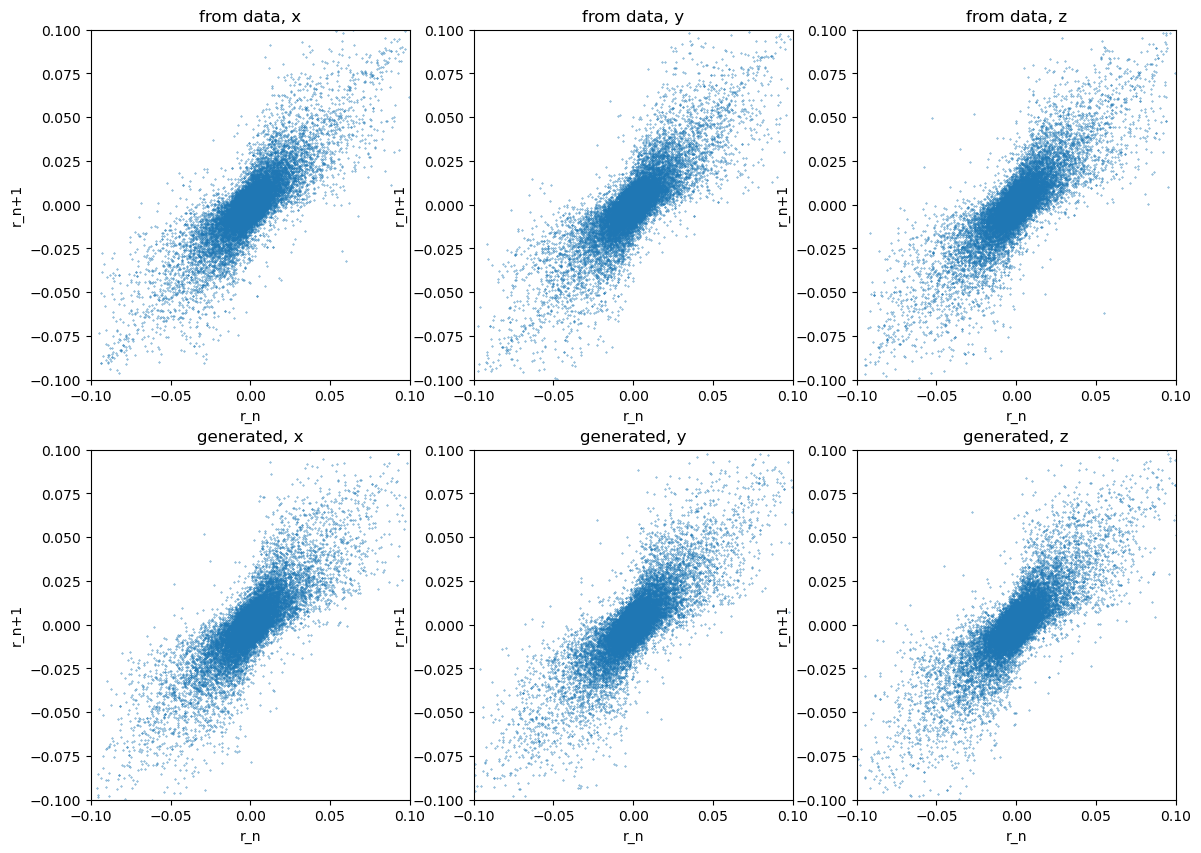

In [13]:
# number of points to plot
nPoints = 30000
b_inds = np.random.choice(nTrajs*nTimestepsBench, nPoints)
inds = np.random.choice(nTrajs*nTimesteps, nPoints)

dim_labels = ['x', 'y', 'z']
dim_index = 2 # choose which dimension to plot
ax_lim = 0.1

# The following plots show the distribution r_n+1 | r_n.

fig = plt.figure(figsize=(14,10))

for i, label in enumerate(dim_labels):
    
    # Benchmark data
    ax = fig.add_subplot(2,3, i+1)
    ax.scatter(b_rAuxT[:, :, i].flatten()[b_inds], b_rNxtT[:, :, i].flatten()[b_inds], s=0.1)
    ax.set_xlabel('r_n')
    ax.set_ylabel('r_n+1')
    ax.set_title(f'from data, {label}')
    ax.set_xlim([-ax_lim,ax_lim])
    ax.set_ylim([-ax_lim,ax_lim])
    
    # Reduced data
    ax2 = fig.add_subplot(2,3, i+4)
    ax2.scatter(rAuxT[0, :, :, i].flatten()[inds], rNxtT[0, :, :, i].flatten()[inds], s=0.1)
    ax2.set_xlabel('r_n')
    ax2.set_ylabel('r_n+1')
    ax2.set_title(f'generated, {label}')
    ax2.set_xlim([-ax_lim,ax_lim])
    ax2.set_ylim([-ax_lim,ax_lim])
    
fig.show()

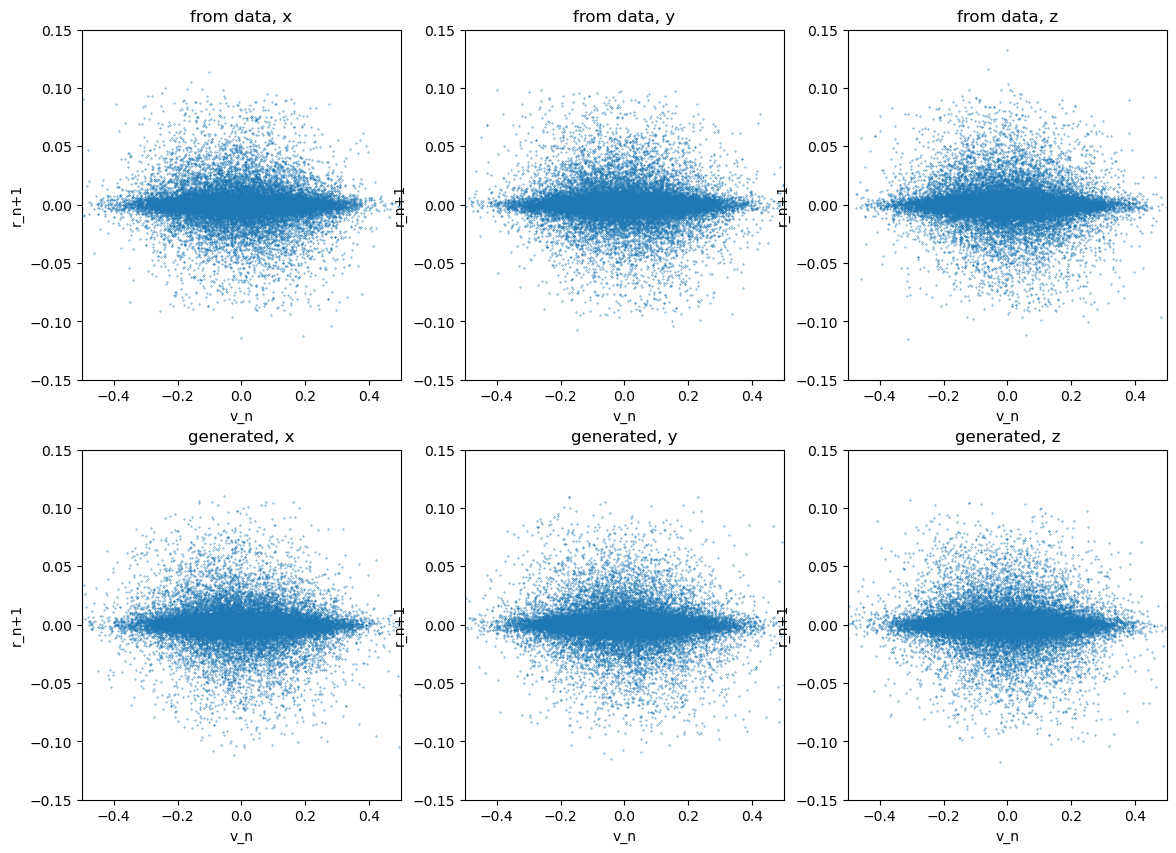

In [19]:
fig = plt.figure(figsize=(14,10))
ax_lim = 0.5
ay_lim = 0.15

for i, label in enumerate(dim_labels):
    
    # Benchmark
    ax = fig.add_subplot(2,3, i+1)
    ax.scatter(b_vT[:, :, i].flatten()[b_inds], b_rNxtT[:, :, i].flatten()[b_inds], s=0.1)
    ax.set_xlabel('v_n')
    ax.set_ylabel('r_n+1')
    ax.set_title(f'from data, {label}')
    ax.set_xlim([-ax_lim,ax_lim])
    ax.set_ylim([-ay_lim,ay_lim])
    
    # Generated
    ax2 = fig.add_subplot(2,3, i+4)
    ax2.scatter(vT[0, :, :, i].flatten()[inds], rNxtT[0, :, :, i].flatten()[inds], s=0.1)
    ax2.set_xlabel('v_n')
    ax2.set_ylabel('r_n+1')
    ax2.set_title(f'generated, {label}')
    ax2.set_xlim([-ax_lim,ax_lim])
    ax2.set_ylim([-ay_lim,ay_lim])
    
fig.show()

In [20]:
colors = ["tab:red", "tab:blue", "tab:green", "tab:orange", "tab:purple"]

def plot_pos_vel_distributions(b_qT, b_vT, qT, vT, model_labels=None, n_samples=50000):
    """
    Plots position and velocity marginal distributions for benchmark and reduced models.

    Args:
        b_qT : tensor [n_traj, n_steps, 3] -- benchmark positions
        b_vT : tensor [n_traj, n_steps, 3] -- benchmark velocities
        qT   : tensor [n_models, n_traj, n_steps, 3]
        vT   : tensor [n_models, n_traj, n_steps, 3]
        model_labels : list of str of length n_models (optional)
        n_samples : int -- number of random samples from each source
    """

    # -------------------------------------------------------
    # 1. Prepare labels
    # -------------------------------------------------------
    n_models = qT.shape[0]
    if model_labels is None:
        model_labels = [f"Model {i}" for i in range(n_models)]

    # -------------------------------------------------------
    # 2. Random subsampling (for speed)
    # -------------------------------------------------------
    def sample_tensor(x, maxN):
        flat = x.reshape(-1, x.shape[-1])
        N = flat.shape[0]
        idx = np.random.choice(N, size=min(N, maxN), replace=False)
        return flat[idx].cpu().numpy()

    b_q_s = sample_tensor(b_qT, n_samples)   # [N, 3]
    b_v_s = sample_tensor(b_vT, n_samples)

    q_s = [sample_tensor(qT[i], n_samples) for i in range(n_models)]
    v_s = [sample_tensor(vT[i], n_samples) for i in range(n_models)]

    # -------------------------------------------------------
    # 3. Plotting
    # -------------------------------------------------------
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    dims = ["x", "y", "z"]

    # --------------------------
    # Position distributions
    # --------------------------
    for d in range(3):
        ax = axes[0, d]

        # Benchmark KDE
        kde_b = gaussian_kde(b_q_s[:, d])
        xs = np.linspace(b_q_s[:, d].min(), b_q_s[:, d].max(), 400)
        ax.plot(xs, kde_b(xs), color="black", lw=2, label="Benchmark")

        # Reduced models
        for m in range(n_models):
            kde_m = gaussian_kde(q_s[m][:, d])
            ax.plot(xs, kde_m(xs), ls="--", lw=1.5,
                    color=colors[m % len(colors)],
                    label=model_labels[m] if d == 0 else None)

        ax.set_title(f"Position distribution: {dims[d]}")
        ax.set_xlabel(f"q_{dims[d]}")
        ax.set_ylabel("Density")

    # --------------------------
    # Velocity distributions
    # --------------------------
    for d in range(3):
        ax = axes[1, d]

        # Benchmark KDE
        kde_b = gaussian_kde(b_v_s[:, d])
        xs = np.linspace(b_v_s[:, d].min(), b_v_s[:, d].max(), 400)
        ax.plot(xs, kde_b(xs), color="black", lw=2, label="Benchmark")

        # Reduced models
        for m in range(n_models):
            kde_m = gaussian_kde(v_s[m][:, d])
            ax.plot(xs, kde_m(xs), ls="--", lw=1.5,
                    color=colors[m % len(colors)],
                    label=model_labels[m] if d == 0 else None)

        ax.set_title(f"Velocity distribution: {dims[d]}")
        ax.set_xlabel(f"v_{dims[d]}")
        ax.set_ylabel("Density")

    # --------------------------
    # Final formatting
    # --------------------------
    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=12)
    plt.tight_layout()
    plt.show()

In [21]:
def plot_acf_results(ACF_FFT, t_lags, reducedLabels):
    """
    Plot distance (position) ACF and velocity ACF for benchmark + reduced models.

    ACF_FFT: array of shape [1 + nModels, 2, lag]
        [:, 0, :] → position ACF
        [:, 1, :] → velocity ACF
    t_lags: time axis in physical units
    labels: list of labels, length 1 + nModels
    """
    nModels = ACF_FFT.shape[0] - 1
    assert len(reducedLabels) == nModels
    
    labels = ["Benchmark"]
    for i in range(nModels):
        labels.append(reducedLabels[i])
        
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --------------------------
    # Position ACF (left panel)
    # --------------------------
    ax = axes[0]
    for i in range(nModels + 1):
        ax.plot(
            t_lags, 
            ACF_FFT[i, 0], 
            label=labels[i], 
            lw=2 if i == 0 else 1.5,
            color="black" if i==0 else colors[i-1],
            linestyle='-' if i == 0 else '--'
        )
    ax.set_title("Position ACF", fontsize=14)
    ax.set_xlabel("time (ns)", fontsize=12)
    ax.set_ylabel("ACF", fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)

    # --------------------------
    # Velocity ACF (right panel)
    # --------------------------
    ax = axes[1]
    for i in range(nModels + 1):
        ax.plot(
            t_lags, 
            ACF_FFT[i, 1], 
            label=labels[i],
            lw=2 if i == 0 else 1.5,
            color="black" if i==0 else colors[i-1],
            linestyle='-' if i == 0 else '--'
        )
    ax.set_title("Velocity ACF", fontsize=14)
    ax.set_xlabel("time (ns)", fontsize=12)
    ax.set_ylabel("ACF", fontsize=12)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [22]:
# CALCULATING AUTOCORRELATION FUNCTIONS.
#print(sind, eind)
lagtimesteps = 2000
mTrajs = 20
t_lags = np.arange(lagtimesteps)*0.05

def correlation_fft(a, b, trunc):
    """Calculates correlation via FFT."""
    len_a = len(a)
    a = np.concatenate([a, np.zeros(len_a)])
    b = np.concatenate([b, np.zeros(len_a)])
    a_fft = np.fft.fft(a)
    b_fft = np.fft.fft(b)
    corr = np.fft.ifft(a_fft * np.conj(b_fft))
    corr = corr[:trunc].real
    corr /= np.linspace(len_a, len_a - trunc + 1, trunc)
    return corr

In [23]:
def plot_acf_results(ACF_FFT, t_lags, reducedLabels):
    """
    Plot distance (position) ACF and velocity ACF for benchmark + reduced models.

    ACF_FFT: array of shape [1 + nModels, 2, lag]
        [:, 0, :] → position ACF
        [:, 1, :] → velocity ACF
    t_lags: time axis in physical units
    labels: list of labels, length 1 + nModels
    """
    nModels = ACF_FFT.shape[0] - 1
    assert len(reducedLabels) == nModels
    
    labels = ["Benchmark"]
    for i in range(nModels):
        labels.append(reducedLabels[i])
        
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --------------------------
    # Position ACF (left panel)
    # --------------------------
    ax = axes[0]
    for i in range(nModels + 1):
        ax.plot(
            t_lags, 
            ACF_FFT[i, 0], 
            label=labels[i], 
            lw=2 if i == 0 else 1.5,
            color="black" if i==0 else colors[i-1],
            linestyle='-' if i == 0 else '--'
        )
    ax.set_title("Position ACF", fontsize=14)
    ax.set_xlabel("time (ns)", fontsize=12)
    ax.set_ylabel("ACF", fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)

    # --------------------------
    # Velocity ACF (right panel)
    # --------------------------
    ax = axes[1]
    for i in range(nModels + 1):
        ax.plot(
            t_lags, 
            ACF_FFT[i, 1], 
            label=labels[i],
            lw=2 if i == 0 else 1.5,
            color="black" if i==0 else colors[i-1],
            linestyle='-' if i == 0 else '--'
        )
    ax.set_title("Velocity ACF", fontsize=14)
    ax.set_xlabel("time (ns)", fontsize=12)
    ax.set_ylabel("ACF", fontsize=12)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [26]:
# CALCULATING AUTOCORRELATION FUNCTIONS.

# ACF by FFT for 1-D traj, then summing up over vector dimensions and all trajs 
ACF_FFT = np.zeros((1+nModels, 2, lagtimesteps))
    
for trajInd in np.random.choice(nTrajs, mTrajs):
    
    #print('Benchmark')
    # position
    ACF_FFT[0, 0] += np.sum([correlation_fft(b_qT[trajInd, :, i], b_qT[trajInd, :, i], lagtimesteps) for i in range(b_qT.shape[2])], axis=0)
    # velocity
    ACF_FFT[0, 1] += np.sum([correlation_fft(b_vT[trajInd, :, i], b_vT[trajInd, :, i], lagtimesteps) for i in range(b_vT.shape[2])], axis=0)
    
    for i in range(nModels):
        #print('Reduced')
        ACF_FFT[i+1, 0] += np.sum([correlation_fft(qT[i, trajInd, :, d], qT[i, trajInd, :, d], lagtimesteps) for d in range(qT.shape[3])], axis=0)
        ACF_FFT[i+1, 1] += np.sum([correlation_fft(vT[i, trajInd, :, d], vT[i, trajInd, :, d], lagtimesteps) for d in range(vT.shape[3])], axis=0)
    
    #ACF_FFT[0] += np.sum([correlation_fft(b_vTraj[:, i], b_vTraj[:, i], lagtimesteps) for i in range(b_vTraj.shape[1])], axis=0)
    #ACF_FFT[1] += np.sum([correlation_fft(vTraj[:, i], vTraj[:, i], lagtimesteps) for i in range(vTraj.shape[1])], axis=0)
    
ACF_FFT[0, 0] /= ACF_FFT[0, 0, 0]
ACF_FFT[0, 1] /= ACF_FFT[0, 1, 0]

for i in range(nModels):
    ACF_FFT[i+1, 0] /= ACF_FFT[i+1, 0, 0]
    ACF_FFT[i+1, 1] /= ACF_FFT[i+1, 1, 0]

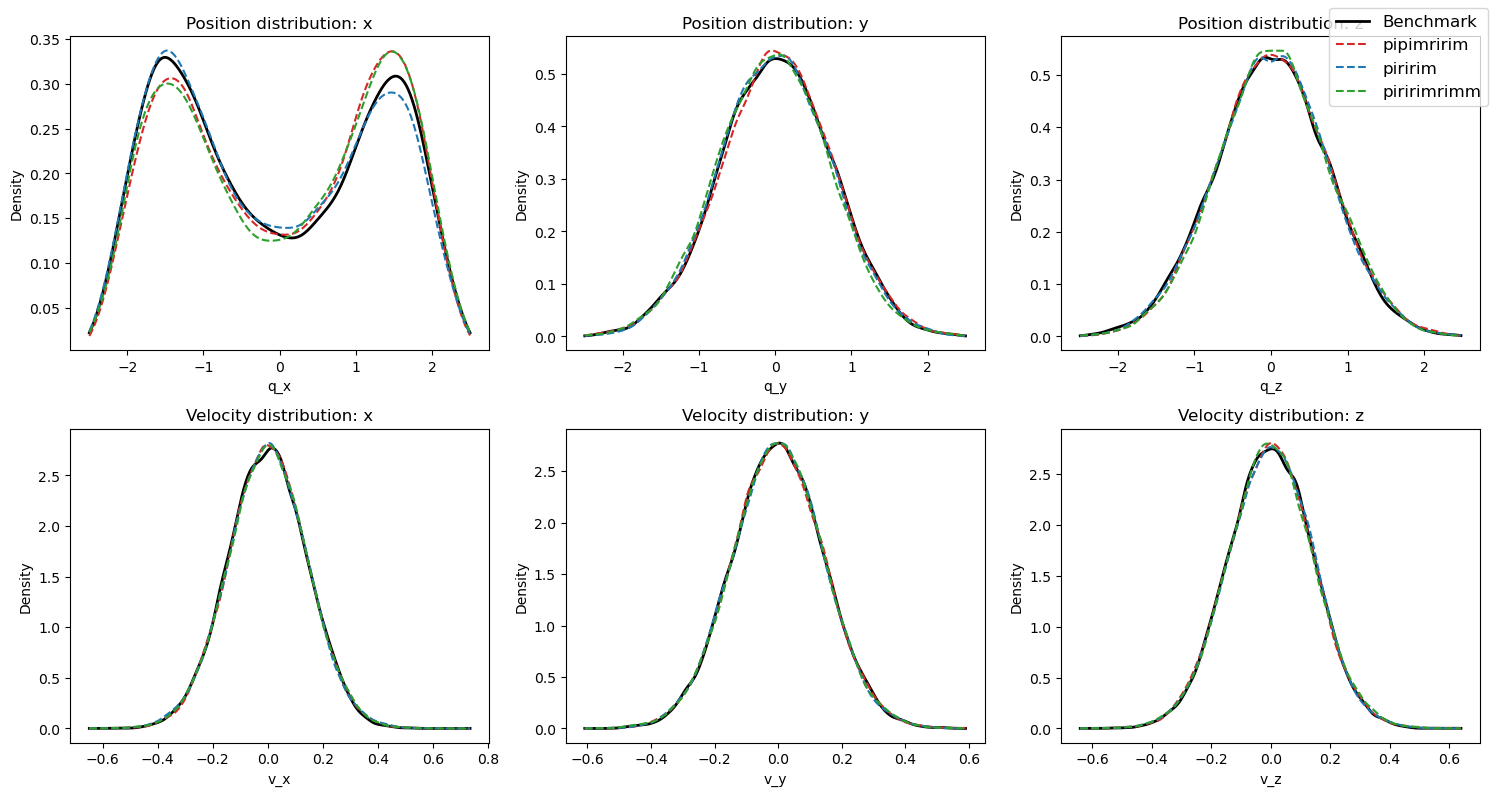

In [27]:
plot_pos_vel_distributions(
    b_qT, b_vT,
    qT, vT,
    model_labels=datasetLabels
)

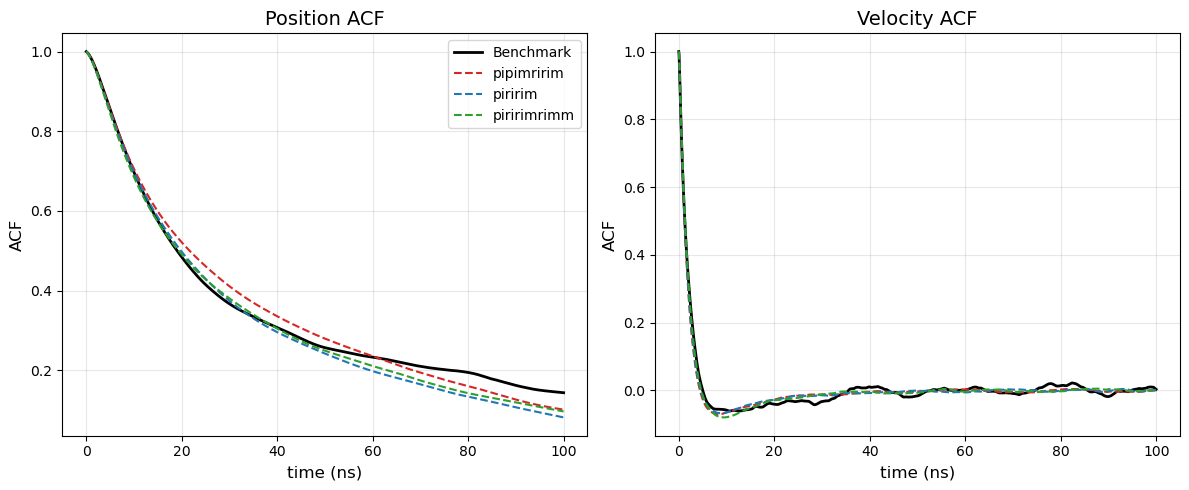

In [28]:
plot_acf_results(ACF_FFT, t_lags, datasetLabels)

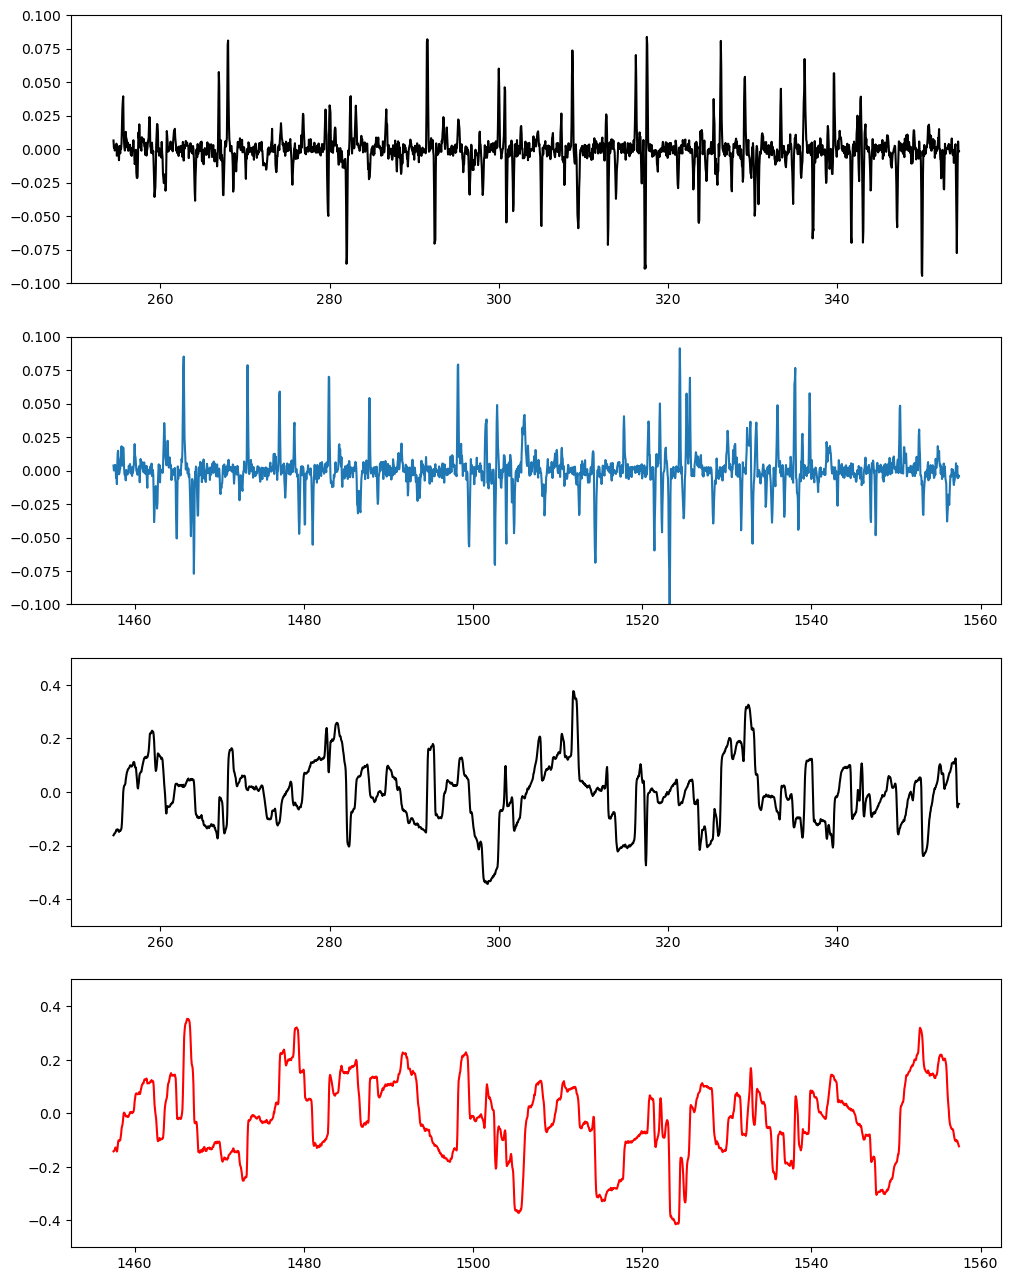

In [13]:
# Plotting R_AUX and V along the trajectory.

plotlength = 2000

x = np.random.randint(nTrajs) # selecting random trajectory.
b_t = b_timesteps[x, :]
t = timesteps[0, x, :]

b_randind = np.random.choice(len(b_t)-2*plotlength)
randind = np.random.choice(len(t)-2*plotlength)
b_endind = b_randind+plotlength
endind = randind+plotlength

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(12,16))

# Benchmark
ax1.plot(b_t[b_randind:b_endind], b_rAuxT[x, b_randind:b_endind, 0], 'k')
ax1.set_ylim([-0.1, 0.1])
ax3.plot(b_t[b_randind:b_endind], b_vT[x, b_randind:b_endind, 0], 'k')
ax3.set_ylim([-0.5, 0.5])

# Reduced model
ax2.plot(t[randind:endind], rAuxT[mID, x, randind:endind, 0])
ax2.set_ylim([-0.1, 0.1])
ax4.plot(t[randind:endind], vT[mID, x, randind:endind, 0], 'r')
ax4.set_ylim([-0.5, 0.5])

fig.show()

In [14]:
#Calculating the Mean Squared Displacement of the particle.
b_rT = torch.norm(b_qT, dim=-1)
b_diffsq = torch.diff(b_rT, dim=-1)**2
b_MSD = torch.mean(b_diffsq)

rT = torch.norm(qT, dim=-1)
diffsq = torch.diff(rT, dim=-1)**2
MSD = torch.mean(diffsq, dim=(1,2))

print('Mean Square Displacement:')
print('Benchmark:', float(b_MSD))
print('Model 1:', float(MSD[0]))
if mID_2 is not None:
    print('Model 2:', float(MSD[1]))
if mID_3 is not None:
    print('Model 3:', float(MSD[2]))

Mean Square Displacement:
Benchmark: 4.991572131984867e-05
Model 1: 5.1203693146817386e-05
Model 2: 5.159260399523191e-05
Model 3: 5.1661623729160056e-05


(2, 10)


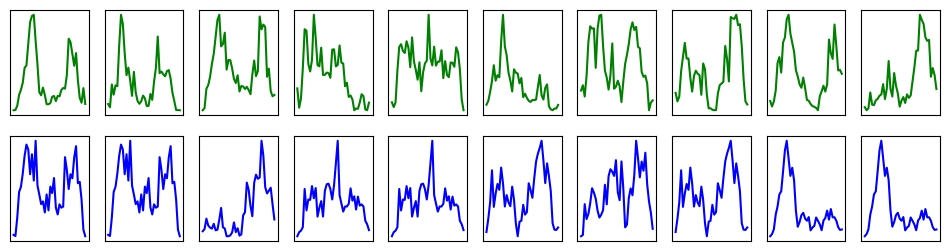

In [15]:
# Truncating
truncate = True

if truncate==True:
            
    sind = np.random.randint(4999, 190000) # starting ind for full-time trajectories
    eind = sind + nTimestepsBench

else:
    sind = 0
    eind = 200000

fig, axes = plt.subplots(2, 10, figsize=(12,3))
print(axes.shape)

trajInds = np.sort(np.random.choice(nTrajs, 10, replace=False))

for i, ind in enumerate(trajInds):
    
    # Benchmark
    pos, binEdges = np.histogram(b_qT[ind, :, 0], bins=numbins, density=True);
    binsPos = 0.5 * (binEdges[1:] + binEdges[:-1])
    axes[0, i].plot(binsPos, pos, c='g')
    
    # Reduced model
    pos, binEdges = np.histogram(qT[0, ind, sind:eind, 0], bins=numbins, density=True);
    binsPos = 0.5 * (binEdges[1:] + binEdges[:-1])
    axes[1, i].plot(binsPos, pos, c='b')
    
    axes[0, i].axes.get_xaxis().set_ticks([])
    axes[0, i].axes.get_yaxis().set_ticks([])
    axes[1, i].axes.get_xaxis().set_ticks([])
    axes[1, i].axes.get_yaxis().set_ticks([])